In [3]:
#Load dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('/kaggle/input/titanic-dataset/Titanic-Dataset.csv')



In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#Missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
#Creating new column family size based on number of siblings/spouses and parents/children aboard
df['FamilySize'] = df['SibSp'] + df['Parch']



In [9]:
#Creating new column IsAlone based on SibSp and Parch
df['IsAlone'] = df['SibSp'] + df['Parch']==0

In [10]:
#Checking to see if null values were filled and new column is created
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    bool   
dtypes: bool(1), float64(2), int64(6), object(5)
memory usage: 91.5+ KB


In [11]:
#Converting categorical features
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [12]:
#Predicting survival based on pclass, age,sex, fare using logistic regression
survival_features = ['Pclass','Sex','Age', 'Fare']
X = df[survival_features]
y = df['Survived']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coeff_df = pd.DataFrame({
    'Feature': survival_features,
    'Coefficient': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
})


In [13]:
y_predict_survival=model.predict(X)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_survival=accuracy_score(y,y_predict_survival)
print (accuracy_survival)

0.7991021324354658


In [27]:
# Predict Survival if Pclass is 1,sex is female, age is 20 and fare is 13
new_passenger = np.array([[1, 1, 20, 13]])  # [Pclass, Sex, Age, Fare]

# Predict survival
predicted_survival = model.predict(new_passenger)

# Output prediction result
print("Predicted Survival:", "Survived" if predicted_survival[0] == 1 else "Did Not Survive")

Predicted Survival: Survived


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


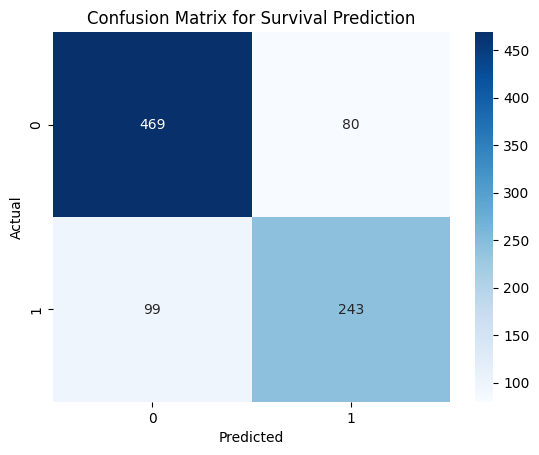

In [15]:
#Confusion Matrix for survival
conf_matrix = confusion_matrix(y, y_predict_survival)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Survival Prediction")
plt.show()

In [16]:
#Predicting passenger class using fare,family size,age, logistic regression
X_pclass = df[["Fare", "FamilySize","Age","Embarked"]]
y_pclass = df["Pclass"]
log_reg_pclass = LogisticRegression(multi_class='ovr', max_iter=200)
log_reg_pclass.fit(X_pclass, y_pclass)
y_pred_pclass = log_reg_pclass.predict(X_pclass)
accuracy_pclass = accuracy_score(y_pclass, y_pred_pclass)
print(accuracy_pclass)

0.792368125701459


In [33]:
#Predicting passenger class if fare is 20,Family size is 3, Age is 15 and Embarked from C
new_passenger_1 = np.array([[20, 3, 15, 1]]) 

# Predict Class
predicted_class= log_reg_pclass.predict(new_passenger_1)

# Output prediction result
print("Predicted class is:",predicted_class)

Predicted class is: [3]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Confusion Matrix:
[[207   1   8]
 [ 15  17 152]
 [  8   1 482]]


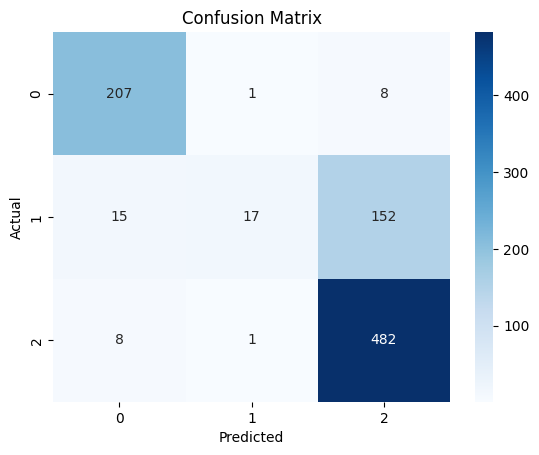

In [41]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_pclass, y_pred_pclass)
print("Confusion Matrix:")
print(conf_matrix)

# Plotting the Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
#Predicting Embarkation Port- Logistic Regression
X_embark = df[["Pclass", "Fare", "Age", "FamilySize"]]
y_embark = df["Embarked"]
log_reg_embark = LogisticRegression(multi_class='ovr', max_iter=200)
log_reg_embark.fit(X_embark, y_embark)
y_pred_embark = log_reg_embark.predict(X_embark)
accuracy_embark = accuracy_score(y_embark, y_pred_embark)
print(accuracy_embark)


0.7306397306397306


In [34]:
# Predict Embarkation Port if Pclass is 3, age is 20, fare is 25, FamilySize is 2
new_passenger_2 = np.array([[3, 25, 20, 2]])  

# Predict survival
predicted_embarkationport = log_reg_embark.predict(new_passenger_2)

# Output prediction result
print("Embarkation Port", predicted_embarkationport)

Embarkation Port [0]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


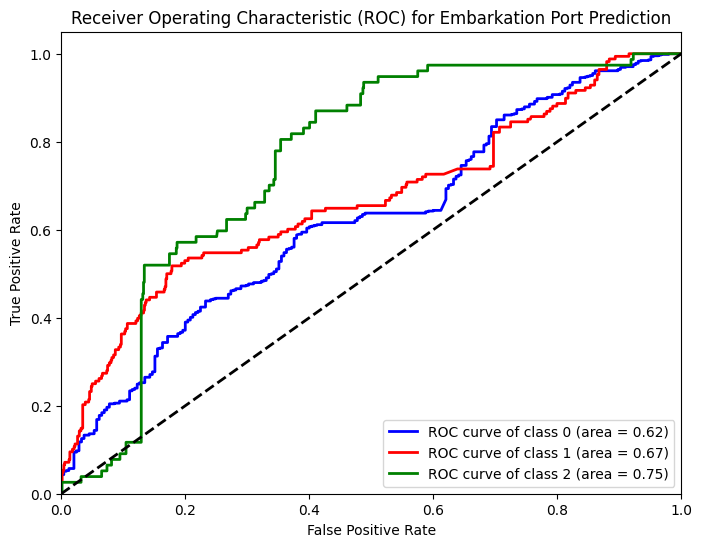

In [43]:
# ROC Curve and AUC for each class
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

y_embark_bin = label_binarize(y_embark, classes=[0, 1, 2])
n_classes = y_embark_bin.shape[1]

# Predict probabilities for each class
y_score = log_reg_embark.predict_proba(X_embark)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_embark_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Embarkation Port Prediction')
plt.legend(loc="lower right")
plt.show()


In [19]:
# Predicting Family Status (Alone vs. With Family)
df['Family'] = df['SibSp'] + df['Parch']
df['IsAlone'] = df['Family'].apply(lambda x: 1 if x == 0 else 0)
X_family = df[["Pclass", "Fare", "Age", "Embarked"]]
y_family = df["IsAlone"]
log_reg_family = LogisticRegression()
log_reg_family.fit(X_family, y_family)
y_pred_family = log_reg_family.predict(X_family)
accuracy_family = accuracy_score(y_family, y_pred_family)
print(accuracy_family)

0.7250280583613917


In [36]:
#Predict is alone or with family if Pclass is 2, Fare is 25, Age is 30, Embarked 1= queenstown
new_passenger_family = np.array([[2, 25, 30, 1]])  # [Pclass, Fare, Age, Embarked]

# Predict family status (IsAlone: 1 = Alone, 0 = With Family)
predicted_family_status = log_reg_family.predict(new_passenger_family)

# Output prediction result
print("Predicted Family Status:", "Alone" if predicted_family_status[0] == 1 else "With Family")

Predicted Family Status: Alone


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [37]:
### Linear Regression (Predicting Continuous Variables)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Predicting Fare
X_fare = df[["Pclass", "Age", "FamilySize", "Embarked"]]
y_fare = df["Fare"]
lin_reg_fare = LinearRegression()
lin_reg_fare.fit(X_fare, y_fare)
y_pred_fare = lin_reg_fare.predict(X_fare)
mse_fare = mean_squared_error(y_fare, y_pred_fare)
print(f"MSE for Fare Prediction: {mse_fare:.2f}")

MSE for Fare Prediction: 1530.48


In [47]:
#Evaluating model
from sklearn.metrics import mean_squared_error, r2_score
mse_fare = mean_squared_error(y_fare, y_pred_fare)
rmse_fare = np.sqrt(mse_fare)
r2_fare = r2_score(y_fare, y_pred_fare)

print(f"Mean Squared Error (Fare): {mse_fare}")
print(f"Root Mean Squared Error (Fare): {rmse_fare}")
print(f"R-squared (Fare): {r2_fare}")

Mean Squared Error (Fare): 1530.4755890407496
Root Mean Squared Error (Fare): 39.12129329458255
R-squared (Fare): 0.3795365825308331


In [38]:
#Predict Fare- pclass is 2, age is 10,familysize is 1, embarked 0
new_passenger_fare = np.array([[2, 10, 1, 0]])  


predicted_fare = lin_reg_fare.predict(new_passenger_fare)

# Output prediction result
print("Predicted Fare:", predicted_fare)

Predicted Fare: [43.42296554]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


<function matplotlib.pyplot.show(close=None, block=None)>

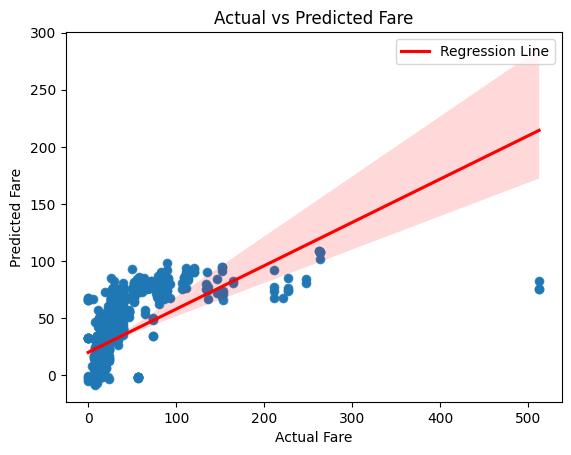

In [50]:
sns.scatterplot(x=y_fare,y=y_pred_fare)
sns.regplot(x=y_fare, y=y_pred_fare, scatter_kws={'label': 'Data Points'}, line_kws={'color': 'red', 'label': 'Regression Line'})
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.legend()
plt.show

In [39]:
# Predicting Age
X_age = df[["Pclass", "Fare", "FamilySize", "Embarked"]]
y_age = df["Age"]
lin_reg_age = LinearRegression()
lin_reg_age.fit(X_age, y_age)
y_pred_age = lin_reg_age.predict(X_age)
mse_age = mean_squared_error(y_age, y_pred_age)
print(f"MSE for Age Prediction: {mse_age:.2f}")

MSE for Age Prediction: 140.99


In [51]:
#Evaluating model

mse_age = mean_squared_error(y_age, y_pred_age)
rmse_age = np.sqrt(mse_age)
r2_age = r2_score(y_age, y_pred_age)

print(f"Mean Squared Error (Fare): {mse_age}")
print(f"Root Mean Squared Error (Fare): {rmse_age}")
print(f"R-squared (Fare): {r2_age}")

Mean Squared Error (Fare): 140.98542298432199
Root Mean Squared Error (Fare): 11.873728268085049
R-squared (Fare): 0.16735441336435197


In [40]:
#Predict Age- pclass is 2, fare is 10,familysize is 1, embarked 0
new_passenger_age = np.array([[2, 10, 1, 0]])  


predicted_age = lin_reg_age.predict(new_passenger_age)

# Output prediction result
print("Predicted Age:", predicted_age)

Predicted Age: [31.24846854]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


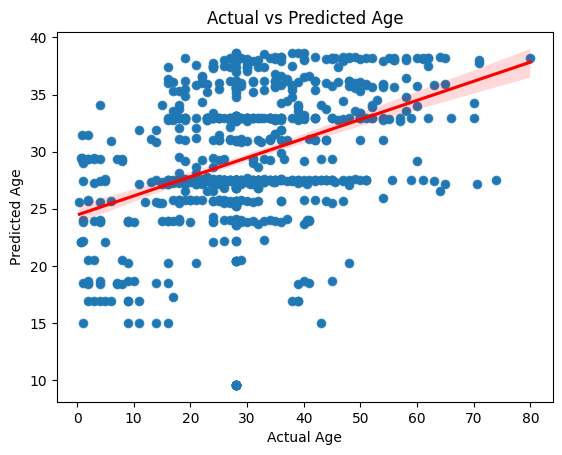

In [53]:
# Visualization for Linear Regression (Age Prediction)
sns.scatterplot(x=y_age, y=y_pred_age)
sns.regplot(x=y_age, y=y_pred_age, scatter_kws={'label': 'Data Points'}, line_kws={'color': 'red', 'label': 'Regression Line'})
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")
plt.show()